# TP3 — Modélisation CLV (Lumina & Co)

Notebook complet pour le **TP3** : construction d’une target CLV (split temporel), feature engineering (15+ features), modélisation (baseline + modèles non-linéaires), évaluation, et interprétation.

## Prérequis
- Un fichier **transactions_clean.csv** (issu du TP1/TP2) contenant au minimum :
  `customer_id, invoice_id, invoice_date, product_code, country, quantity, unit_price`.
- La colonne `line_total` sera recalculée si absente.

> ⚠️ Anti data leakage : toutes les features sont calculées uniquement sur la **période d'observation**. La target CLV est calculée uniquement sur la **période future**.

---

## 0) Setup & chargement des données

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path
pd.set_option("display.max_columns", 250)

# === Chemin vers le dataset nettoyé ===
DATA_PATH = "transactions_clean.csv"  # modifie si besoin (ex: "data/transactions_clean.csv")

assert Path(DATA_PATH).exists(), f"Fichier introuvable: {DATA_PATH}. Mets le bon chemin dans DATA_PATH."

df = pd.read_csv(DATA_PATH)

# Dates
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

# Sécurité types
df["customer_id"] = df["customer_id"].astype(str)
df["invoice_id"] = df["invoice_id"].astype(str)

# line_total
if "line_total" not in df.columns:
    df["line_total"] = df["quantity"] * df["unit_price"]

# Retire lignes critiques manquantes
df = df.dropna(subset=["customer_id","invoice_id","invoice_date","line_total"])

print("Lignes:", len(df))
print("Clients uniques:", df["customer_id"].nunique())
print("Invoices uniques:", df["invoice_id"].nunique())
df.head()

Lignes: 1346758
Clients uniques: 48866
Invoices uniques: 218671


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,line_total
0,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,13.20
1,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,14.75
2,702453,33347.0,22135,CURIOUS IMAGES GIFT WRAP SET,60.0,0.65,2011-01-02 12:20:00,United Kingdom,39.00
3,554808,17059.0,21166,COOK WITH WINE METAL SIGN,1.0,2.08,2011-05-26 13:01:00,United Kingdom,2.08
4,490817,15311.0,35004S,SET OF 3 SILVER FLYING DUCKS,12.0,1.95,2009-12-08 12:33:00,United Kingdom,23.40


---
## Étape 1 — Construction de la target CLV (split temporel)

Principe :
- **Observation window** : 12 premiers mois → features
- **Target window** : 12 mois suivants → CLV (somme dépensée)

On fixe les bornes à partir de la date min du dataset (pas la date du jour).

In [3]:
start_date = df["invoice_date"].min()

obs_end = start_date + pd.DateOffset(months=12)
target_end = obs_end + pd.DateOffset(months=12)

print("Observation :", start_date, "→", obs_end)
print("Target      :", obs_end, "→", target_end)

df_obs = df[(df["invoice_date"] >= start_date) & (df["invoice_date"] < obs_end)].copy()
df_target = df[(df["invoice_date"] >= obs_end) & (df["invoice_date"] < target_end)].copy()

print("Transactions observation:", len(df_obs))
print("Transactions target     :", len(df_target))
print("Clients obs:", df_obs["customer_id"].nunique())
print("Clients target:", df_target["customer_id"].nunique())

Observation : 2007-07-06 12:20:00 → 2008-07-06 12:20:00
Target      : 2008-07-06 12:20:00 → 2009-07-06 12:20:00
Transactions observation: 2084
Transactions target     : 28500
Clients obs: 639
Clients target: 6009


### Target supervisée : CLV sur 12 mois futurs

In [4]:
clv_target = (
    df_target.groupby("customer_id")["line_total"]
    .sum()
    .rename("CLV_12m")
)

print("Clients avec CLV>0 en target:", int((clv_target > 0).sum()))
clv_target.head()

Clients avec CLV>0 en target: 6009


customer_id
21467.0    214.20
21470.0     72.00
21584.0    130.80
21664.0     20.80
21712.0     20.28
Name: CLV_12m, dtype: float64

---
## Étape 2 — Feature engineering (15+ features) sur la période d'observation

### 2.1 Snapshot observation + RFM de base

In [5]:
snapshot_obs = df_obs["invoice_date"].max() + pd.Timedelta(days=1)

feat = df_obs.groupby("customer_id").agg(
    last_purchase=("invoice_date", "max"),
    first_purchase=("invoice_date", "min"),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum"),
)

feat["recency"] = (snapshot_obs - feat["last_purchase"]).dt.days
feat["tenure_days"] = (snapshot_obs - feat["first_purchase"]).dt.days
feat["avg_basket"] = feat["monetary"] / feat["frequency"]

feat = feat.drop(columns=["last_purchase","first_purchase"])
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket
customer_id,,,,,
23236.0,1,30.00,52,52,30.00
23241.0,1,23.55,69,69,23.55
23259.0,1,15.25,46,46,15.25
23281.0,1,17.85,20,20,17.85
23293.0,1,15.00,227,227,15.00


### 2.2 Diversité produits + intensité panier

In [6]:
feat["n_distinct_products"] = df_obs.groupby("customer_id")["product_code"].nunique()

avg_items = (
    df_obs.groupby(["customer_id","invoice_id"])
    .size()
    .groupby("customer_id")
    .mean()
)
feat["avg_items_per_order"] = avg_items
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order
customer_id,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0
23241.0,1,23.55,69,69,23.55,2,2.0
23259.0,1,15.25,46,46,15.25,2,2.0
23281.0,1,17.85,20,20,17.85,1,1.0
23293.0,1,15.00,227,227,15.00,1,1.0


### 2.3 Activité temporelle : mois actifs, fréquence normalisée, dépense normalisée

In [7]:
df_obs["year_month"] = df_obs["invoice_date"].dt.to_period("M")

feat["n_active_months"] = df_obs.groupby("customer_id")["year_month"].nunique()
feat["freq_per_active_month"] = feat["frequency"] / feat["n_active_months"].replace(0, np.nan)
feat["spend_per_day"] = feat["monetary"] / feat["tenure_days"].replace(0, np.nan)

feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day
customer_id,,,,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0,1,1.0,0.576923
23241.0,1,23.55,69,69,23.55,2,2.0,1,1.0,0.341304
23259.0,1,15.25,46,46,15.25,2,2.0,1,1.0,0.331522
23281.0,1,17.85,20,20,17.85,1,1.0,1,1.0,0.892500
23293.0,1,15.00,227,227,15.00,1,1.0,1,1.0,0.066079


### 2.4 Régularité : écart-type des délais entre achats

In [8]:
def interpurchase_std(dates: pd.Series):
    dates = dates.sort_values()
    diffs = dates.diff().dt.days.dropna()
    if len(diffs) == 0:
        return 0.0
    return float(diffs.std())

feat["std_interpurchase"] = (
    df_obs.groupby("customer_id")["invoice_date"]
    .apply(interpurchase_std)
)

feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day,std_interpurchase
customer_id,,,,,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0,1,1.0,0.576923,NaN
23241.0,1,23.55,69,69,23.55,2,2.0,1,1.0,0.341304,NaN
23259.0,1,15.25,46,46,15.25,2,2.0,1,1.0,0.331522,NaN
23281.0,1,17.85,20,20,17.85,1,1.0,1,1.0,0.892500,0.0
23293.0,1,15.00,227,227,15.00,1,1.0,1,1.0,0.066079,0.0


### 2.5 Saisonnalité (ratio achats en mois de pics)

In [9]:
peak_months = [11, 12]  # à adapter si besoin

df_obs["is_peak"] = df_obs["invoice_date"].dt.month.isin(peak_months)
feat["peak_ratio"] = df_obs.groupby("customer_id")["is_peak"].mean()

first_purchase_obs = df_obs.groupby("customer_id")["invoice_date"].min()
feat["first_purchase_month"] = first_purchase_obs.dt.month

feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day,std_interpurchase,peak_ratio,first_purchase_month
customer_id,,,,,,,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0,1,1.0,0.576923,NaN,0.0,5
23241.0,1,23.55,69,69,23.55,2,2.0,1,1.0,0.341304,NaN,0.0,4
23259.0,1,15.25,46,46,15.25,2,2.0,1,1.0,0.331522,NaN,0.0,5
23281.0,1,17.85,20,20,17.85,1,1.0,1,1.0,0.892500,0.0,0.0,6
23293.0,1,15.00,227,227,15.00,1,1.0,1,1.0,0.066079,0.0,1.0,11


### 2.6 Tendance de dépense mensuelle (spending_trend)

In [10]:
from sklearn.linear_model import LinearRegression

def spending_trend(customer_df: pd.DataFrame):
    monthly = (
        customer_df.set_index("invoice_date")
        .resample("ME")["line_total"]
        .sum()
        .reset_index()
    )
    if len(monthly) < 2:
        return 0.0
    X = np.arange(len(monthly)).reshape(-1,1)
    y = monthly["line_total"].values
    model = LinearRegression()
    model.fit(X, y)
    return float(model.coef_[0])

feat["spending_trend"] = df_obs.groupby("customer_id").apply(spending_trend)
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day,std_interpurchase,peak_ratio,first_purchase_month,spending_trend
customer_id,,,,,,,,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0,1,1.0,0.576923,NaN,0.0,5,0.0
23241.0,1,23.55,69,69,23.55,2,2.0,1,1.0,0.341304,NaN,0.0,4,0.0
23259.0,1,15.25,46,46,15.25,2,2.0,1,1.0,0.331522,NaN,0.0,5,0.0
23281.0,1,17.85,20,20,17.85,1,1.0,1,1.0,0.892500,0.0,0.0,6,0.0
23293.0,1,15.00,227,227,15.00,1,1.0,1,1.0,0.066079,0.0,1.0,11,0.0


### 2.7 Pays dominant

In [11]:
feat["country"] = (
    df_obs.groupby("customer_id")["country"]
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
)
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day,std_interpurchase,peak_ratio,first_purchase_month,spending_trend,country
customer_id,,,,,,,,,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0,1,1.0,0.576923,NaN,0.0,5,0.0,United Kingdom
23241.0,1,23.55,69,69,23.55,2,2.0,1,1.0,0.341304,NaN,0.0,4,0.0,Portugal
23259.0,1,15.25,46,46,15.25,2,2.0,1,1.0,0.331522,NaN,0.0,5,0.0,United Kingdom
23281.0,1,17.85,20,20,17.85,1,1.0,1,1.0,0.892500,0.0,0.0,6,0.0,United Kingdom
23293.0,1,15.00,227,227,15.00,1,1.0,1,1.0,0.066079,0.0,1.0,11,0.0,Germany


### 2.8 Assemblage features + target (left join)

In [12]:
model_df = (
    feat.merge(clv_target, left_index=True, right_index=True, how="left")
        .fillna({"CLV_12m": 0})
)

print("Shape model_df:", model_df.shape)
display(model_df.head())

print("CLV_12m > 0 (%):", round((model_df["CLV_12m"] > 0).mean()*100, 2))
model_df["CLV_12m"].describe()

Shape model_df: (639, 16)


,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day,std_interpurchase,peak_ratio,first_purchase_month,spending_trend,country,CLV_12m
customer_id,,,,,,,,,,,,,,,,
23236.0,1,30.00,52,52,30.00,2,2.0,1,1.0,0.576923,NaN,0.0,5,0.0,United Kingdom,0.0
23241.0,1,23.55,69,69,23.55,2,2.0,1,1.0,0.341304,NaN,0.0,4,0.0,Portugal,0.0
23259.0,1,15.25,46,46,15.25,2,2.0,1,1.0,0.331522,NaN,0.0,5,0.0,United Kingdom,0.0
23281.0,1,17.85,20,20,17.85,1,1.0,1,1.0,0.892500,0.0,0.0,6,0.0,United Kingdom,0.0
23293.0,1,15.00,227,227,15.00,1,1.0,1,1.0,0.066079,0.0,1.0,11,0.0,Germany,0.0


CLV_12m > 0 (%): 19.41


count     639.000000
mean       51.140031
std       303.390133
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      5821.250000
Name: CLV_12m, dtype: float64

---
## Étape 3 — Modélisation & évaluation

### 3.1 Encodage + split temporel + target log

In [13]:
model_df["CLV_log"] = np.log1p(model_df["CLV_12m"])

if "country" in model_df.columns:
    model_df_enc = pd.get_dummies(model_df, columns=["country"], drop_first=True)
else:
    model_df_enc = model_df.copy()

sort_col = "tenure_days" if "tenure_days" in model_df_enc.columns else "recency"
model_df_sorted = model_df_enc.sort_values(sort_col).reset_index(drop=True)
print("Tri pour split:", sort_col)

split_idx = int(len(model_df_sorted) * 0.8)
train = model_df_sorted.iloc[:split_idx].copy()
test  = model_df_sorted.iloc[split_idx:].copy()

X_train = train.drop(columns=["CLV_12m","CLV_log"], errors="ignore")
y_train = train["CLV_log"]

X_test  = test.drop(columns=["CLV_12m","CLV_log"], errors="ignore")
y_test  = test["CLV_log"]

print("Train:", train.shape, " Test:", test.shape)
X_train.head()

Tri pour split: tenure_days
Train: (511, 27)  Test: (128, 27)


,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,n_active_months,freq_per_active_month,spend_per_day,std_interpurchase,peak_ratio,first_purchase_month,spending_trend,country_Cyprus,country_Denmark,country_Germany,country_Japan,country_Norway,country_Portugal,country_Sweden,country_USA,country_United Arab Emirates,country_United Kingdom,country_Unspecified
0,1,19.50,1,1,19.50,1,1.0,1,1.0,19.50,0.0,0.0,7,0.0,False,False,False,False,False,False,False,False,False,True,False
1,1,34.80,1,1,34.80,2,2.0,1,1.0,34.80,NaN,0.0,7,0.0,False,False,False,False,False,False,False,False,False,True,False
2,1,588.00,1,1,588.00,2,2.0,1,1.0,588.00,NaN,0.0,7,0.0,False,False,False,False,False,False,False,False,False,True,False
3,1,46.28,1,1,46.28,2,2.0,1,1.0,46.28,NaN,0.0,7,0.0,False,False,False,False,False,False,False,False,False,True,False
4,1,15.30,1,1,15.30,1,1.0,1,1.0,15.30,0.0,0.0,7,0.0,False,False,False,False,False,False,False,False,False,True,False


### 3.2 Modèles : Linear Regression, Random Forest, XGBoost

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [18]:
import numpy as np

# Remplacer inf par NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

# Imputation : médianes calculées sur TRAIN (anti leakage)
medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)

print("NaN train:", X_train.isna().sum().sum())
print("NaN test :", X_test.isna().sum().sum())

NaN train: 0
NaN test : 0


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def eval_regression(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

results = []

# Linear Regression (scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr_log = lr.predict(X_test_scaled)
rmse, mae, r2 = eval_regression(y_test, pred_lr_log)
results.append(("Linear Regression", rmse, mae, r2, pred_lr_log))

# Random Forest
rf = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf_log = rf.predict(X_test)
rmse, mae, r2 = eval_regression(y_test, pred_rf_log)
results.append(("Random Forest", rmse, mae, r2, pred_rf_log))

# XGBoost (si dispo)
pred_xgb_log = None
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=900,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)
    pred_xgb_log = xgb.predict(X_test)
    rmse, mae, r2 = eval_regression(y_test, pred_xgb_log)
    results.append(("XGBoost", rmse, mae, r2, pred_xgb_log))
except Exception as e:
    print("XGBoost indisponible / erreur:", e)

res_df = pd.DataFrame([(m, rmse, mae, r2) for m, rmse, mae, r2, _ in results],
                      columns=["Model","RMSE","MAE","R2"]).sort_values("RMSE")
display(res_df)

best_model = res_df.iloc[0]["Model"]
print("Meilleur modèle (RMSE min):", best_model)

XGBoost indisponible / erreur: No module named 'xgboost'


,Model,RMSE,MAE,R2
1,Random Forest,45.191017,17.243594,-0.001844
0,Linear Regression,71.104450,38.130617,-1.480216


Meilleur modèle (RMSE min): Random Forest


### 3.3 Scatter réel vs prédit (meilleur modèle)

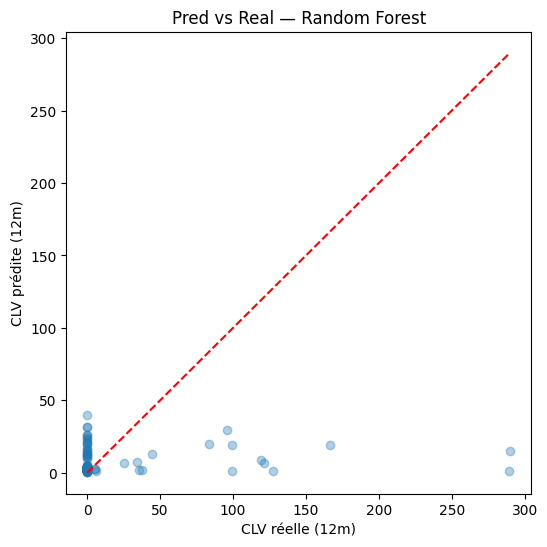

In [20]:
pred_map = {m: p for m, _, _, _, p in results}
best_pred_log = pred_map[best_model]

y_true = np.expm1(y_test)
y_pred = np.expm1(best_pred_log)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.35)
plt.xlabel("CLV réelle (12m)")
plt.ylabel("CLV prédite (12m)")
plt.title(f"Pred vs Real — {best_model}")

mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.show()

---
## Étape 4 — Interprétation (importance des variables)

monetary                  0.244621
avg_basket                0.166249
spend_per_day             0.166043
recency                   0.097322
tenure_days               0.094984
n_distinct_products       0.078078
avg_items_per_order       0.064990
frequency                 0.021040
first_purchase_month      0.015695
std_interpurchase         0.013179
spending_trend            0.010407
country_United Kingdom    0.007074
country_Cyprus            0.005711
freq_per_active_month     0.003943
country_Germany           0.003894
dtype: float64

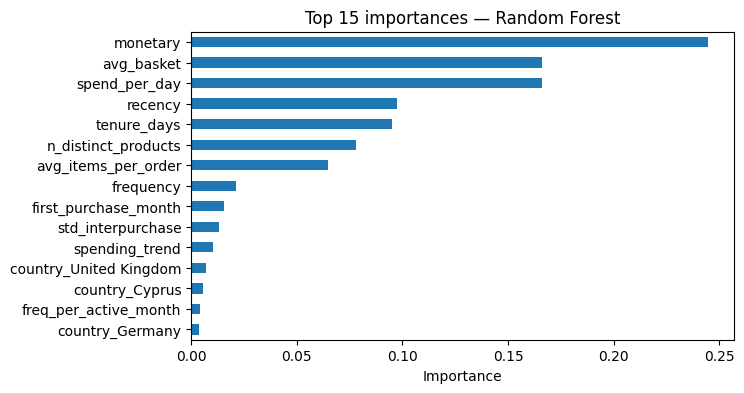

In [21]:
feature_names = list(X_train.columns)

if best_model == "Random Forest":
    imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(imp.head(15))

    plt.figure(figsize=(7,4))
    imp.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 importances — Random Forest")
    plt.xlabel("Importance")
    plt.show()

elif best_model == "XGBoost" and pred_xgb_log is not None:
    imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(imp.head(15))

    plt.figure(figsize=(7,4))
    imp.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 importances — XGBoost")
    plt.xlabel("Importance")
    plt.show()

else:
    coefs = pd.Series(lr.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
    display(coefs.head(15))

### (Optionnel) SHAP (si installé)

In [22]:
# !pip install shap

try:
    import shap

    if best_model == "XGBoost" and pred_xgb_log is not None:
        explainer = shap.TreeExplainer(xgb)
        sample = X_test.sample(min(1000, len(X_test)), random_state=42)
        shap_values = explainer.shap_values(sample)

        shap.summary_plot(shap_values, sample, show=False)
        plt.show()
    elif best_model == "Random Forest":
        explainer = shap.TreeExplainer(rf)
        sample = X_test.sample(min(1000, len(X_test)), random_state=42)
        shap_values = explainer.shap_values(sample)

        shap.summary_plot(shap_values, sample, show=False)
        plt.show()
    else:
        print("SHAP: modèle non supporté dans ce bloc.")
except Exception as e:
    print("SHAP indisponible / erreur:", e)

SHAP indisponible / erreur: No module named 'shap'


---
## Étape 5 — Conclusion (gabarit)

In [23]:
print(f"""Résumé (à copier en Markdown) :

- Target : CLV_12m construite sur 12 mois futurs (target window), features sur 12 mois passés (observation window).
- Split : 80/20 sans shuffle (trié par {sort_col}).
- Meilleur modèle : {best_model}.
- Métriques (test) :\n{res_df.to_string(index=False)}

Interprétation : commenter les top features et en déduire des leviers marketing.
Limites : skewness CLV, outliers, biais géographique, période limitée.
""")

Résumé (à copier en Markdown) :

- Target : CLV_12m construite sur 12 mois futurs (target window), features sur 12 mois passés (observation window).
- Split : 80/20 sans shuffle (trié par tenure_days).
- Meilleur modèle : Random Forest.
- Métriques (test) :
            Model      RMSE       MAE        R2
    Random Forest 45.191017 17.243594 -0.001844
Linear Regression 71.104450 38.130617 -1.480216

Interprétation : commenter les top features et en déduire des leviers marketing.
Limites : skewness CLV, outliers, biais géographique, période limitée.

